# 04 — Regression & Matrix Plots (Preetham's Seaborn Mastery Series)

Part 4 of 5. Covers `regplot`, `lmplot`, `residplot`, `heatmap`, and `clustermap`.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')

## 1. `regplot()` — Scatter + Linear Regression Line

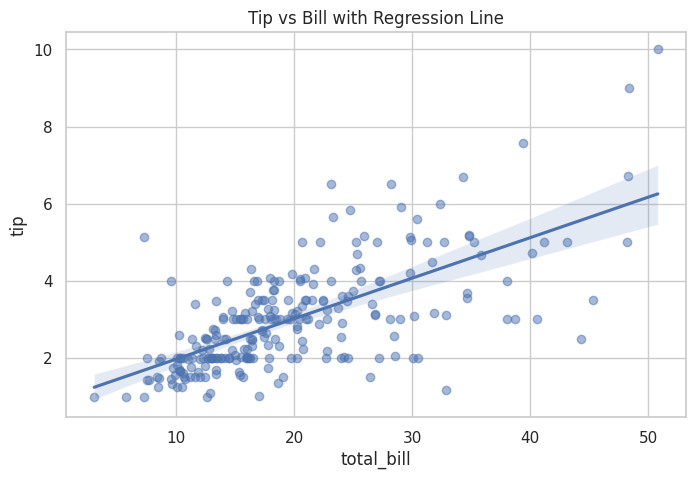

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='total_bill', y='tip', data=tips, ax=ax, scatter_kws={'alpha':0.5})
ax.set_title('Tip vs Bill with Regression Line')
plt.show()

## 2. `regplot()` with Polynomial Fit (`order=2`)

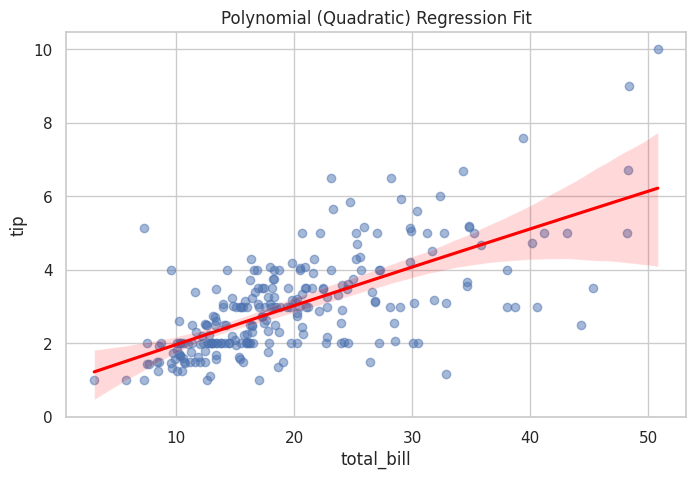

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='total_bill', y='tip', data=tips, order=2, ax=ax, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax.set_title('Polynomial (Quadratic) Regression Fit')
plt.show()

## 3. `lmplot()` — Figure-Level Regression with Facets

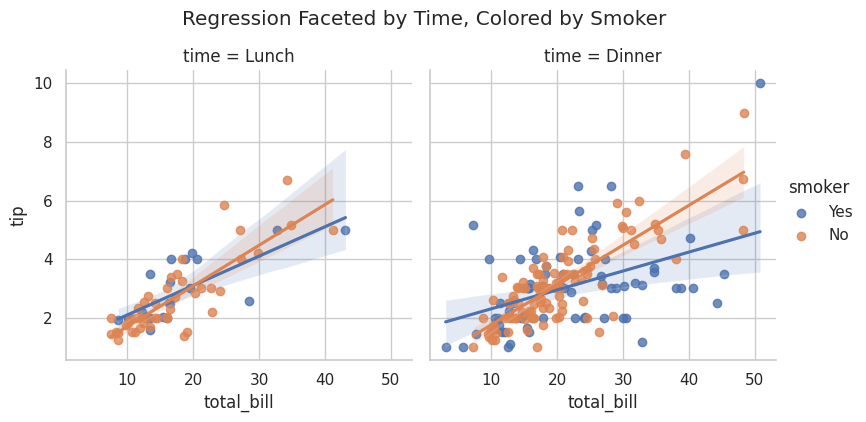

In [4]:
g = sns.lmplot(x='total_bill', y='tip', data=tips, col='time', hue='smoker', height=4)
g.fig.suptitle('Regression Faceted by Time, Colored by Smoker', y=1.05)
plt.show()

## 4. `residplot()` — Checking Regression Residuals

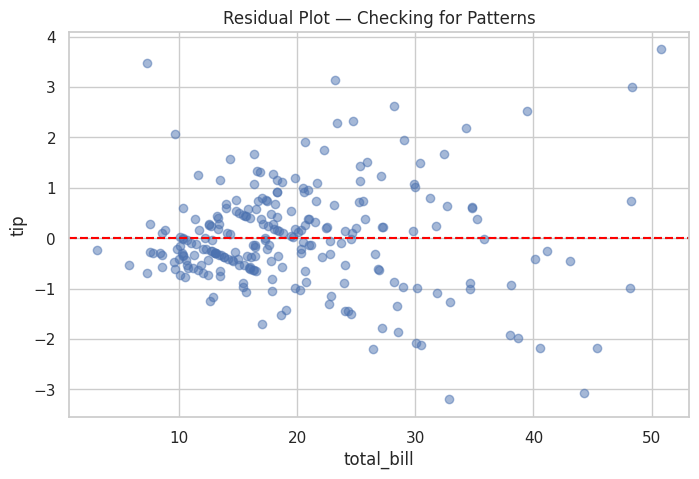

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.residplot(x='total_bill', y='tip', data=tips, ax=ax, scatter_kws={'alpha':0.5})
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residual Plot — Checking for Patterns')
plt.show()

## 5. `heatmap()` — Correlation Matrix

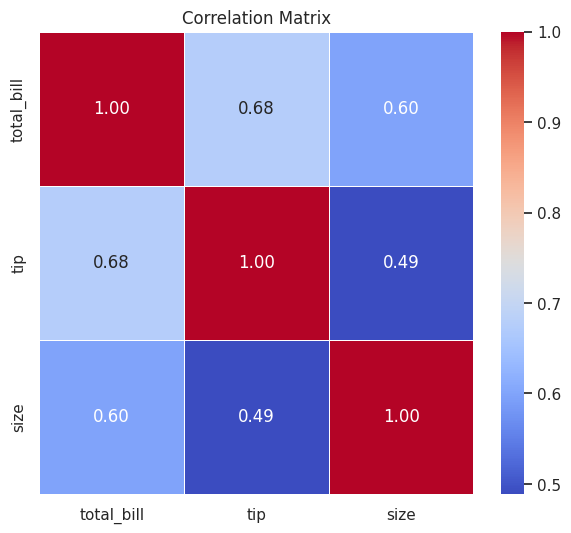

In [6]:
numeric_tips = tips.select_dtypes(include='number')
corr = numeric_tips.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.show()

## 6. `heatmap()` on Pivoted Data — Flights Passengers

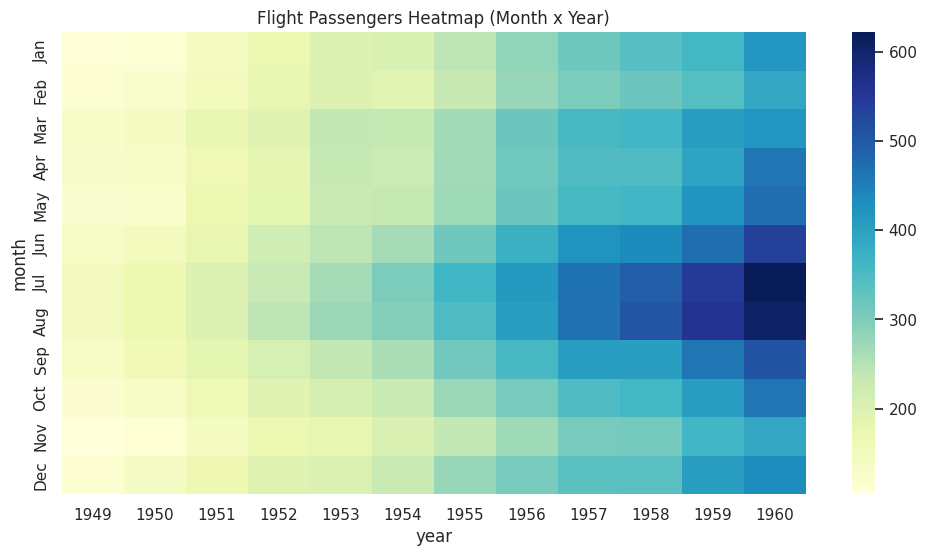

In [7]:
flights_pivot = flights.pivot(index='month', columns='year', values='passengers')
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(flights_pivot, cmap='YlGnBu', annot=False, ax=ax)
ax.set_title('Flight Passengers Heatmap (Month x Year)')
plt.show()

## 7. `heatmap()` — Customizing Colorbar, Masking Upper Triangle

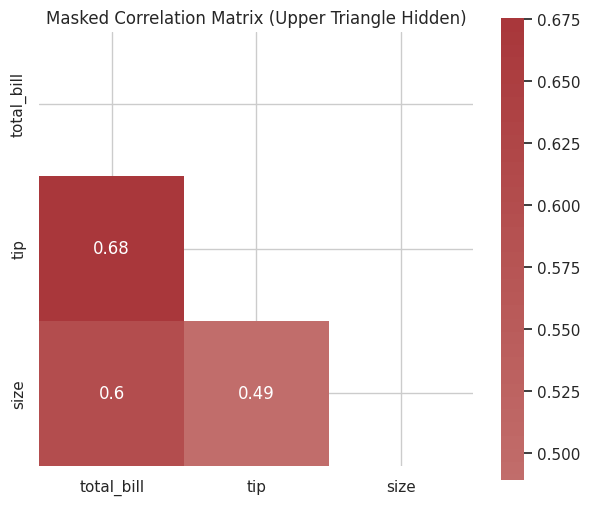

In [8]:
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap='vlag', center=0, ax=ax, square=True)
ax.set_title('Masked Correlation Matrix (Upper Triangle Hidden)')
plt.show()

## 8. `clustermap()` — Hierarchically Clustered Heatmap

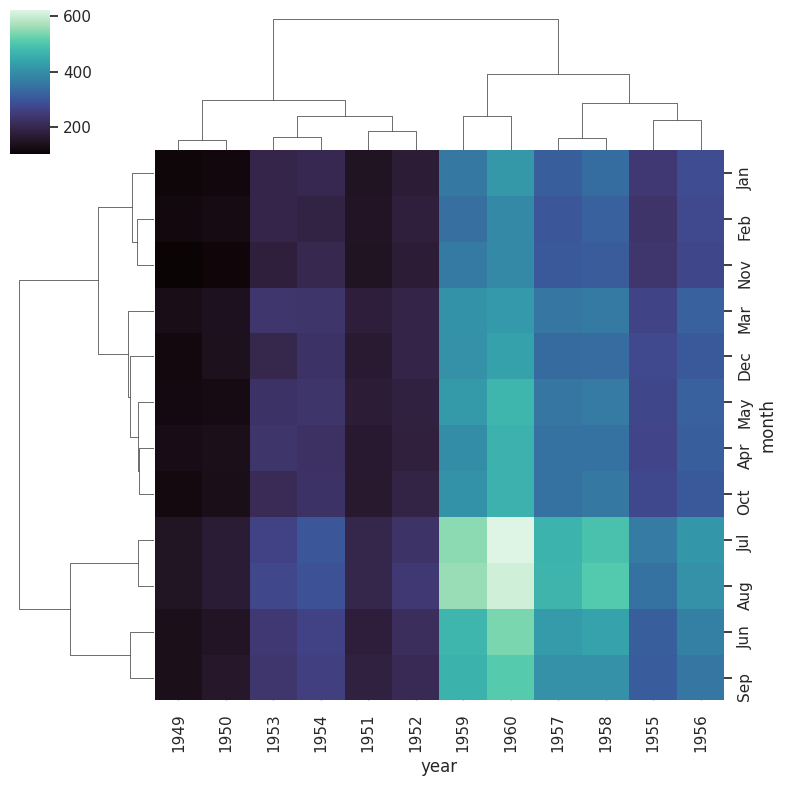

In [9]:
g = sns.clustermap(flights_pivot, cmap='mako', figsize=(8, 8), annot=False)
plt.show()

## 9. Comparing Multiple Regression Fits — `lmplot` with `hue`

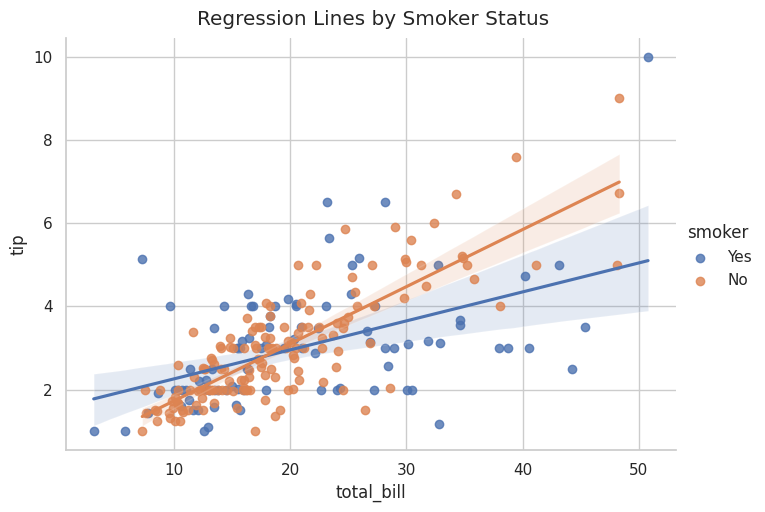

In [10]:
g = sns.lmplot(x='total_bill', y='tip', data=tips, hue='smoker', height=5, aspect=1.4)
g.fig.suptitle('Regression Lines by Smoker Status', y=1.02)
plt.show()

## 10. Logistic Regression Fit — `regplot(logistic=True)`

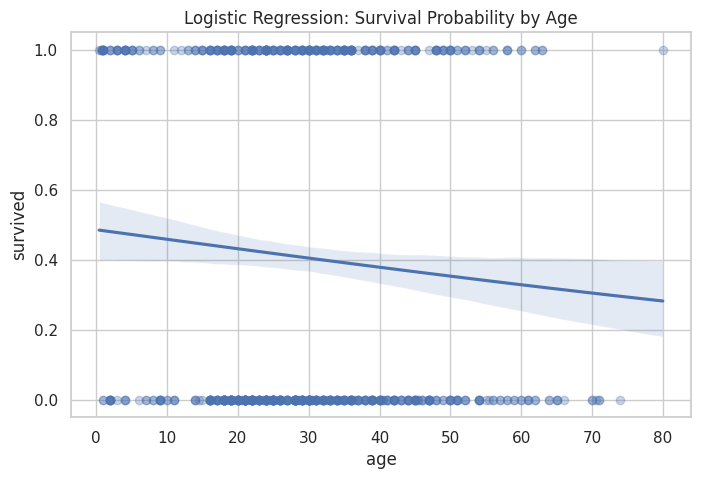

In [11]:
titanic = sns.load_dataset('titanic').dropna(subset=['age'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='age', y='survived', data=titanic, logistic=True, ax=ax, scatter_kws={'alpha':0.3})
ax.set_title('Logistic Regression: Survival Probability by Age')
plt.show()

## 11. Summary — What You Learned

| Plot | Purpose |
|---|---|
| `regplot()` | Scatter + regression line (axes-level) |
| `lmplot()` | Figure-level version with facets |
| `residplot()` | Check regression residuals for patterns |
| `heatmap()` | Correlation matrix / any 2D grid |
| `clustermap()` | Heatmap with hierarchical clustering |

### Next Notebook
Continue to **`05_titanic_eda.ipynb`** — the final real-world project combining everything from this series.